# Analysis for Sacramento State DataFest 2025 

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
leases_df = pd.read_csv('../real-estate-data/Leases.csv')
leases_df.head(20)

,year,quarter,monthsigned,market,building_name,building_id,address,region,city,state,...,overall_rent,direct_available_space,direct_availability_proportion,direct_internal_class_rent,direct_overall_rent,sublet_available_space,sublet_availability_proportion,sublet_internal_class_rent,sublet_overall_rent,leasing
0,2018,Q1,1.0,Atlanta,10 Glenlake North Tower,Atlanta_Central Perimeter_Atlanta_10 Glenlake ...,10 Glenlake Pky NE,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
1,2018,Q1,1.0,Atlanta,100 City View,Atlanta_Northwest_Atlanta_100 City View_3330 C...,3330 Cumberland Blvd,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
2,2018,Q1,1.0,Atlanta,1000 Parkwood,Atlanta_Northwest_Atlanta_1000 Parkwood_1000 P...,1000 Parkwood Cir SE,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
3,2018,Q1,1.0,Atlanta,1100 Circle 75,Atlanta_Northwest_Atlanta_1100 Circle 75_1100 ...,1100 Circle 75 Pky SE,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,715742.0
4,2018,Q1,1.0,Atlanta,1200 Ashwood,Atlanta_Central Perimeter_Atlanta_1200 Ashwood...,1200 Ashwood Pky,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
5,2018,Q1,1.0,Atlanta,1200 Ashwood,Atlanta_Central Perimeter_Atlanta_1200 Ashwood...,1200 Ashwood Pky,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
6,2018,Q1,1.0,Atlanta,2 Sun,Atlanta_Northeast_Peachtree Corners_2 Sun_2 Su...,2 Sun Ct,South,Peachtree Corners,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
7,2018,Q1,1.0,Atlanta,200 Ashford Center North,Atlanta_Central Perimeter_Atlanta_200 Ashford ...,200 Ashford Ctr N,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
8,2018,Q1,1.0,Atlanta,271 17th,Atlanta_Midtown_Atlanta_271 17th_271 17th St NW,271 17th St NW,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0
9,2018,Q1,1.0,Atlanta,271 17th,Atlanta_Midtown_Atlanta_271 17th_271 17th St NW,271 17th St NW,South,Atlanta,GA,...,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126.0


In [28]:
leases_df.shape

(194685, 35)

In [29]:
leases_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194685 entries, 0 to 194684
Data columns (total 35 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   year                            194685 non-null  int64  
 1   quarter                         194685 non-null  object 
 2   monthsigned                     193822 non-null  float64
 3   market                          194685 non-null  object 
 4   building_name                   157999 non-null  object 
 5   building_id                     194685 non-null  object 
 6   address                         194685 non-null  object 
 7   region                          194685 non-null  object 
 8   city                            194685 non-null  object 
 9   state                           194685 non-null  object 
 10  zip                             194684 non-null  float64
 11  internal_submarket              194685 non-null  object 
 12  internal_class  

In [30]:
leases_df.isna().sum()

year                                   0
quarter                                0
monthsigned                          863
market                                 0
building_name                      36686
building_id                            0
address                                0
region                                 0
city                                   0
state                                  0
zip                                    1
internal_submarket                     0
internal_class                         9
leasedSF                               0
company_name                      157469
internal_industry                 168284
transaction_type                     539
internal_market_cluster           118847
costarID                               0
space_type                          7545
CBD_suburban                           0
RBA                                49144
available_space                    49144
availability_proportion            49144
internal_class_r

In [31]:
leases_df.columns

Index(['year', 'quarter', 'monthsigned', 'market', 'building_name',
       'building_id', 'address', 'region', 'city', 'state', 'zip',
       'internal_submarket', 'internal_class', 'leasedSF', 'company_name',
       'internal_industry', 'transaction_type', 'internal_market_cluster',
       'costarID', 'space_type', 'CBD_suburban', 'RBA', 'available_space',
       'availability_proportion', 'internal_class_rent', 'overall_rent',
       'direct_available_space', 'direct_availability_proportion',
       'direct_internal_class_rent', 'direct_overall_rent',
       'sublet_available_space', 'sublet_availability_proportion',
       'sublet_internal_class_rent', 'sublet_overall_rent', 'leasing'],
      dtype='object')

In [32]:
columns_to_exclude = [
    'RBA', 'available_space', 'availability_proportion',
    'internal_class_rent', 'overall_rent',
    'direct_available_space', 'direct_availability_proportion',
    'direct_internal_class_rent', 'direct_overall_rent',
    'sublet_available_space', 'sublet_availability_proportion',
    'sublet_internal_class_rent', 'sublet_overall_rent'
]

leases_no_price_df = leases_df.drop(axis=1, columns=columns_to_exclude)
leases_no_price_df.head(20)

,year,quarter,monthsigned,market,building_name,building_id,address,region,city,state,...,internal_class,leasedSF,company_name,internal_industry,transaction_type,internal_market_cluster,costarID,space_type,CBD_suburban,leasing
0,2018,Q1,1.0,Atlanta,10 Glenlake North Tower,Atlanta_Central Perimeter_Atlanta_10 Glenlake ...,10 Glenlake Pky NE,South,Atlanta,GA,...,A,24736.0,Capital Investment Advisors,Financial Services and Insurance,Expansion,NaN,445509,Relet,Suburban,1205126.0
1,2018,Q1,1.0,Atlanta,100 City View,Atlanta_Northwest_Atlanta_100 City View_3330 C...,3330 Cumberland Blvd,South,Atlanta,GA,...,A,965.0,NaN,NaN,New,NaN,436994,Relet,Suburban,1205126.0
2,2018,Q1,1.0,Atlanta,1000 Parkwood,Atlanta_Northwest_Atlanta_1000 Parkwood_1000 P...,1000 Parkwood Cir SE,South,Atlanta,GA,...,A,2215.0,Efc Moen,NaN,New,NaN,434890,Relet,Suburban,1205126.0
3,2018,Q1,1.0,Atlanta,1100 Circle 75,Atlanta_Northwest_Atlanta_1100 Circle 75_1100 ...,1100 Circle 75 Pky SE,South,Atlanta,GA,...,O,1925.0,NaN,NaN,New,NaN,434720,Relet,Suburban,715742.0
4,2018,Q1,1.0,Atlanta,1200 Ashwood,Atlanta_Central Perimeter_Atlanta_1200 Ashwood...,1200 Ashwood Pky,South,Atlanta,GA,...,A,2404.0,NaN,NaN,New,NaN,437562,Relet,Suburban,1205126.0
5,2018,Q1,1.0,Atlanta,1200 Ashwood,Atlanta_Central Perimeter_Atlanta_1200 Ashwood...,1200 Ashwood Pky,South,Atlanta,GA,...,A,5091.0,NaN,NaN,New,NaN,437562,Relet,Suburban,1205126.0
6,2018,Q1,1.0,Atlanta,2 Sun,Atlanta_Northeast_Peachtree Corners_2 Sun_2 Su...,2 Sun Ct,South,Peachtree Corners,GA,...,A,13207.0,Kimley-Horn,"Construction, Engineering and Architecture",New,NaN,448077,Relet,Suburban,1205126.0
7,2018,Q1,1.0,Atlanta,200 Ashford Center North,Atlanta_Central Perimeter_Atlanta_200 Ashford ...,200 Ashford Ctr N,South,Atlanta,GA,...,A,1179.0,NaN,NaN,New,NaN,437704,Relet,Suburban,1205126.0
8,2018,Q1,1.0,Atlanta,271 17th,Atlanta_Midtown_Atlanta_271 17th_271 17th St NW,271 17th St NW,South,Atlanta,GA,...,A,3273.0,NaN,NaN,New,NaN,5993371,Relet,CBD,1205126.0
9,2018,Q1,1.0,Atlanta,271 17th,Atlanta_Midtown_Atlanta_271 17th_271 17th St NW,271 17th St NW,South,Atlanta,GA,...,A,15795.0,Square,"Technology, Advertising, Media, and Information",New,NaN,5993371,Relet,CBD,1205126.0


In [33]:
leases_nona_df = leases_df.dropna(axis=0)
leases_nona_df.head(20)

,year,quarter,monthsigned,market,building_name,building_id,address,region,city,state,...,overall_rent,direct_available_space,direct_availability_proportion,direct_internal_class_rent,direct_overall_rent,sublet_available_space,sublet_availability_proportion,sublet_internal_class_rent,sublet_overall_rent,leasing
7776,2019,Q1,1.0,Baltimore,Executive Park West,Baltimore_Baltimore County West_Windsor Mill_E...,3200 Lord Baltimore Dr,Northeast,Windsor Mill,MD,...,23.838594,5715274.0,0.0694,20.593518,23.901592,250994.0,0.0030,19.812714,23.045405,333096.0
7842,2019,Q1,1.0,Boston,65 Blue Sky Dr,Boston_Route 128 North_Burlington_65 Blue Sky ...,65 Network Dr,Northeast,Burlington,MA,...,29.911067,14555051.0,0.0580,39.616733,29.056201,3062962.0,0.0122,28.525612,26.273218,2054850.0
7875,2019,Q1,1.0,Boston,Oliver Street Tower,Boston_Financial District_Boston_Oliver Street...,125 High St,Northeast,Boston,MA,...,29.911067,14555051.0,0.0580,39.616733,29.056201,3062962.0,0.0122,28.525612,26.273218,2054850.0
7876,2019,Q1,1.0,Boston,One Beacon Ln,Boston_Route 128 South_Canton_One Beacon Ln_15...,150 Royall St,Northeast,Canton,MA,...,29.911067,13176365.0,0.0525,18.877410,29.056201,1151648.0,0.0046,20.941226,26.273218,1219157.0
7899,2019,Q1,1.0,Boston,Tower at Northwoods,Boston_Route 128 North_Danvers_Tower at Northw...,222 Rosewood Dr,Northeast,Danvers,MA,...,29.911067,14555051.0,0.0580,39.616733,29.056201,3062962.0,0.0122,28.525612,26.273218,2054850.0
8876,2019,Q1,1.0,Los Angeles,Bldg A,Los Angeles_South Bay_Torrance_Bldg A_2355 Cre...,2355 Crenshaw Blvd,West,Torrance,CA,...,38.947765,21331331.0,0.0996,42.208543,39.550654,2995919.0,0.0140,35.495420,34.392686,3506703.0
8877,2019,Q1,1.0,Los Angeles,Bldg A,Los Angeles_South Bay_Torrance_Bldg A_2355 Cre...,2355 Crenshaw Blvd,West,Torrance,CA,...,38.947765,21331331.0,0.0996,42.208543,39.550654,2995919.0,0.0140,35.495420,34.392686,3506703.0
8896,2019,Q1,1.0,Los Angeles,Century Park East,Los Angeles_Century City_Los Angeles_Century P...,1888 Century Park E,West,Los Angeles,CA,...,38.947765,21331331.0,0.0996,42.208543,39.550654,2995919.0,0.0140,35.495420,34.392686,3506703.0
8932,2019,Q1,1.0,Los Angeles,Lantana Center,Los Angeles_Santa Monica_Santa Monica_Lantana ...,3000 W Olympic Blvd,West,Santa Monica,CA,...,38.947765,21331331.0,0.0996,42.208543,39.550654,2995919.0,0.0140,35.495420,34.392686,3506703.0
8943,2019,Q1,1.0,Los Angeles,One Westside,Los Angeles_Westwood/West LA_Los Angeles_One W...,10800-10900 W Pico Blvd,West,Los Angeles,CA,...,38.947765,21331331.0,0.0996,42.208543,39.550654,2995919.0,0.0140,35.495420,34.392686,3506703.0


In [34]:
prices_df = pd.read_csv('../real-estate-data/price-and-availability.csv')
prices_df.head(20)


,year,quarter,market,internal_class,RBA,available_space,availability_proportion,internal_class_rent,overall_rent,direct_available_space,direct_availability_proportion,direct_internal_class_rent,direct_overall_rent,sublet_available_space,sublet_availability_proportion,sublet_internal_class_rent,sublet_overall_rent,leasing
0,2018,Q1,Atlanta,A,101140416,20239067,0.200109,27.655891,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1205126
1,2018,Q1,Atlanta,O,65810449,12728989,0.193419,18.560886,24.345689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,715742
2,2018,Q1,Austin,A,36815073,4281986,0.116311,40.384706,36.596618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1738905
3,2018,Q1,Austin,O,27947525,3360936,0.121082,30.118658,36.596618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185674
4,2018,Q1,Baltimore,A,41033288,6813380,0.166045,27.104835,22.954034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,380750
5,2018,Q1,Baltimore,O,40265706,6531089,0.162200,20.120990,22.954034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,247089
6,2018,Q1,Boston,A,133073672,17127987,0.128711,42.297880,32.409956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2285080
7,2018,Q1,Boston,O,116186937,14486098,0.124679,20.147725,32.409956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,934610
8,2018,Q1,Charlotte,A,35441291,5603221,0.158099,28.589370,26.037735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1130188
9,2018,Q1,Charlotte,O,27835480,3019728,0.108485,20.755558,26.037735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172401


In [35]:
prices_df.shape

(1680, 18)

In [36]:
prices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1680 entries, 0 to 1679
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   year                            1680 non-null   int64  
 1   quarter                         1680 non-null   object 
 2   market                          1680 non-null   object 
 3   internal_class                  1680 non-null   object 
 4   RBA                             1680 non-null   int64  
 5   available_space                 1680 non-null   int64  
 6   availability_proportion         1680 non-null   float64
 7   internal_class_rent             1680 non-null   float64
 8   overall_rent                    1680 non-null   float64
 9   direct_available_space          1380 non-null   float64
 10  direct_availability_proportion  1380 non-null   float64
 11  direct_internal_class_rent      1380 non-null   float64
 12  direct_overall_rent             13

In [37]:
prices_df.isna().sum()

year                                0
quarter                             0
market                              0
internal_class                      0
RBA                                 0
available_space                     0
availability_proportion             0
internal_class_rent                 0
overall_rent                        0
direct_available_space            300
direct_availability_proportion    300
direct_internal_class_rent        300
direct_overall_rent               300
sublet_available_space            300
sublet_availability_proportion    300
sublet_internal_class_rent        300
sublet_overall_rent               300
leasing                             0
dtype: int64

In [38]:
prices_nona_df = prices_df.dropna(axis=1)
prices_nona_df.head(20)

,year,quarter,market,internal_class,RBA,available_space,availability_proportion,internal_class_rent,overall_rent,leasing
0,2018,Q1,Atlanta,A,101140416,20239067,0.200109,27.655891,24.345689,1205126
1,2018,Q1,Atlanta,O,65810449,12728989,0.193419,18.560886,24.345689,715742
2,2018,Q1,Austin,A,36815073,4281986,0.116311,40.384706,36.596618,1738905
3,2018,Q1,Austin,O,27947525,3360936,0.121082,30.118658,36.596618,185674
4,2018,Q1,Baltimore,A,41033288,6813380,0.166045,27.104835,22.954034,380750
5,2018,Q1,Baltimore,O,40265706,6531089,0.162200,20.120990,22.954034,247089
6,2018,Q1,Boston,A,133073672,17127987,0.128711,42.297880,32.409956,2285080
7,2018,Q1,Boston,O,116186937,14486098,0.124679,20.147725,32.409956,934610
8,2018,Q1,Charlotte,A,35441291,5603221,0.158099,28.589370,26.037735,1130188
9,2018,Q1,Charlotte,O,27835480,3019728,0.108485,20.755558,26.037735,172401


In [39]:
major_market_df = pd.read_csv('../real-estate-data/major-market-occupancy.csv')
major_market_df.head(20)

,year,quarter,market,ending_occupancy_proportion,starting_occupancy_proportion,avg_occupancy_proportion
0,2020,Q1,Washington D.C.,0.19,0.98,0.785714
1,2020,Q1,Manhattan,0.08,0.98,0.732857
2,2020,Q1,Chicago,0.14,0.99,0.788571
3,2020,Q1,Houston,0.33,0.99,0.835714
4,2020,Q1,Philadelphia,0.20,0.99,0.817143
5,2020,Q1,San Francisco,0.09,0.99,0.718571
6,2020,Q1,Los Angeles,0.29,0.99,0.831429
7,2020,Q1,Dallas/Ft Worth,0.33,0.99,0.838571
8,2020,Q1,South Bay/San Jose,0.15,0.98,0.751429
9,2020,Q1,Austin,0.26,0.98,0.820000


In [42]:
leases_df.describe()

,year,monthsigned,zip,leasedSF,costarID,RBA,available_space,availability_proportion,internal_class_rent,overall_rent,direct_available_space,direct_availability_proportion,direct_internal_class_rent,direct_overall_rent,sublet_available_space,sublet_availability_proportion,sublet_internal_class_rent,sublet_overall_rent,leasing
count,194685.000000,193822.000000,194684.000000,1.946850e+05,1.946850e+05,1.455410e+05,1.455410e+05,145541.000000,145541.000000,145541.000000,1.216740e+05,121674.000000,121674.000000,121674.000000,1.216740e+05,121674.000000,121674.000000,121674.000000,1.455410e+05
mean,2020.897116,6.398458,54834.565671,7.418951e+03,8.585231e+05,8.734066e+07,1.761325e+07,0.205129,37.162132,39.730471,1.516990e+07,0.090624,38.532872,41.348356,3.067042e+06,0.017164,32.218578,34.264252,1.327221e+06
std,2.053467,3.415922,32228.307406,2.366310e+04,2.098700e+06,5.975856e+07,1.178294e+07,0.059300,16.183660,16.430368,9.717183e+06,0.035829,17.322360,17.641388,2.875391e+06,0.011111,13.148892,12.922946,1.234172e+06
min,2018.000000,1.000000,1420.000000,1.000000e+00,1.100000e+01,2.010185e+07,1.782779e+06,0.057300,16.957171,18.749409,1.544029e+06,0.021800,18.009119,19.990075,1.108040e+05,0.001700,14.149920,16.865199,5.520300e+04
25%,2019.000000,3.000000,22102.000000,1.265000e+03,1.578120e+05,4.641436e+07,8.345927e+06,0.165001,25.050378,28.860444,7.436069e+06,0.064500,25.717730,29.429358,9.483450e+05,0.008600,23.251198,24.678567,5.355900e+05
50%,2021.000000,6.000000,60607.000000,2.578000e+03,2.802520e+05,6.585438e+07,1.415498e+07,0.197558,32.582522,34.004225,1.218762e+07,0.082600,33.578010,35.731458,1.680762e+06,0.014000,28.384836,30.803734,8.893690e+05
75%,2023.000000,9.000000,85004.000000,5.818000e+03,4.306400e+05,1.153246e+08,2.345972e+07,0.247710,43.667669,44.548462,2.121029e+07,0.109500,46.645537,46.250885,4.512948e+06,0.024200,38.640250,39.026963,1.660927e+06
max,2024.000000,12.000000,98499.000000,1.463234e+06,2.024547e+07,2.683833e+08,5.457790e+07,0.414977,94.191224,84.746663,4.092899e+07,0.190500,99.642941,88.438174,1.435339e+07,0.074600,86.324412,81.205996,9.393220e+06


In [43]:
prices_df.describe()

,year,RBA,available_space,availability_proportion,internal_class_rent,overall_rent,direct_available_space,direct_availability_proportion,direct_internal_class_rent,direct_overall_rent,sublet_available_space,sublet_availability_proportion,sublet_internal_class_rent,sublet_overall_rent,leasing
count,1680.000000,1.680000e+03,1.680000e+03,1680.000000,1680.000000,1680.000000,1.380000e+03,1380.000000,1380.000000,1380.000000,1.380000e+03,1380.000000,1380.000000,1380.000000,1.680000e+03
mean,2021.000000,1.210374e+08,2.548078e+07,0.205361,35.878965,36.743271,1.129815e+07,0.088918,37.072325,37.991738,2.336641e+06,0.018385,31.103258,32.052277,1.735510e+06
std,2.000596,3.219143e+08,6.989460e+07,0.059459,14.197553,13.495467,8.279923e+06,0.034895,15.481108,14.669157,2.208911e+06,0.011575,12.204792,11.848340,4.913469e+06
min,2018.000000,2.007686e+07,1.782779e+06,0.057300,16.957171,18.749409,1.544029e+06,0.021800,18.009119,19.990075,8.283300e+04,0.001500,14.149920,16.865199,5.260500e+04
25%,2019.000000,3.493160e+07,6.078274e+06,0.164501,26.342746,28.279018,5.122876e+06,0.062700,26.518484,28.972157,8.697325e+05,0.010000,23.525936,24.477567,3.866975e+05
50%,2021.000000,4.986687e+07,1.049070e+07,0.200153,31.618035,32.290506,8.802652e+06,0.081350,32.404554,32.257719,1.470552e+06,0.015300,27.279092,28.026234,6.687965e+05
75%,2023.000000,7.877950e+07,1.832050e+07,0.244071,41.165751,41.072908,1.455561e+07,0.110550,42.041934,42.846595,3.132071e+06,0.025000,35.312264,37.565071,1.164113e+06
max,2024.000000,2.171302e+09,6.045432e+08,0.414977,94.191224,84.746663,4.092899e+07,0.190500,99.642941,88.438174,1.435339e+07,0.074600,86.324412,81.205996,4.687655e+07


In [44]:
major_market_df.describe()

,year,ending_occupancy_proportion,starting_occupancy_proportion,avg_occupancy_proportion
count,190.000000,190.000000,190.000000,190.000000
mean,2021.894737,0.351158,0.377895,0.401402
std,1.376090,0.152696,0.195277,0.160338
min,2020.000000,0.080000,0.050000,0.052308
25%,2021.000000,0.220000,0.240000,0.284231
50%,2022.000000,0.355000,0.355000,0.410385
75%,2023.000000,0.470000,0.450000,0.488462
max,2024.000000,0.660000,0.990000,0.838571


In [48]:
unemployment_df = pd.read_csv('../real-estate-data/unemployment.csv')
unemployment_df.head(20)

,year,quarter,month,state,unemployment_rate
0,2018,Q1,1,AZ,4.9
1,2018,Q1,1,CA,4.4
2,2018,Q1,1,CO,2.9
3,2018,Q1,1,DE,4.1
4,2018,Q1,1,DC,5.9
5,2018,Q1,1,FL,3.9
6,2018,Q1,1,GA,4.3
7,2018,Q1,1,IL,4.6
8,2018,Q1,1,MD,4.1
9,2018,Q1,1,MA,3.7


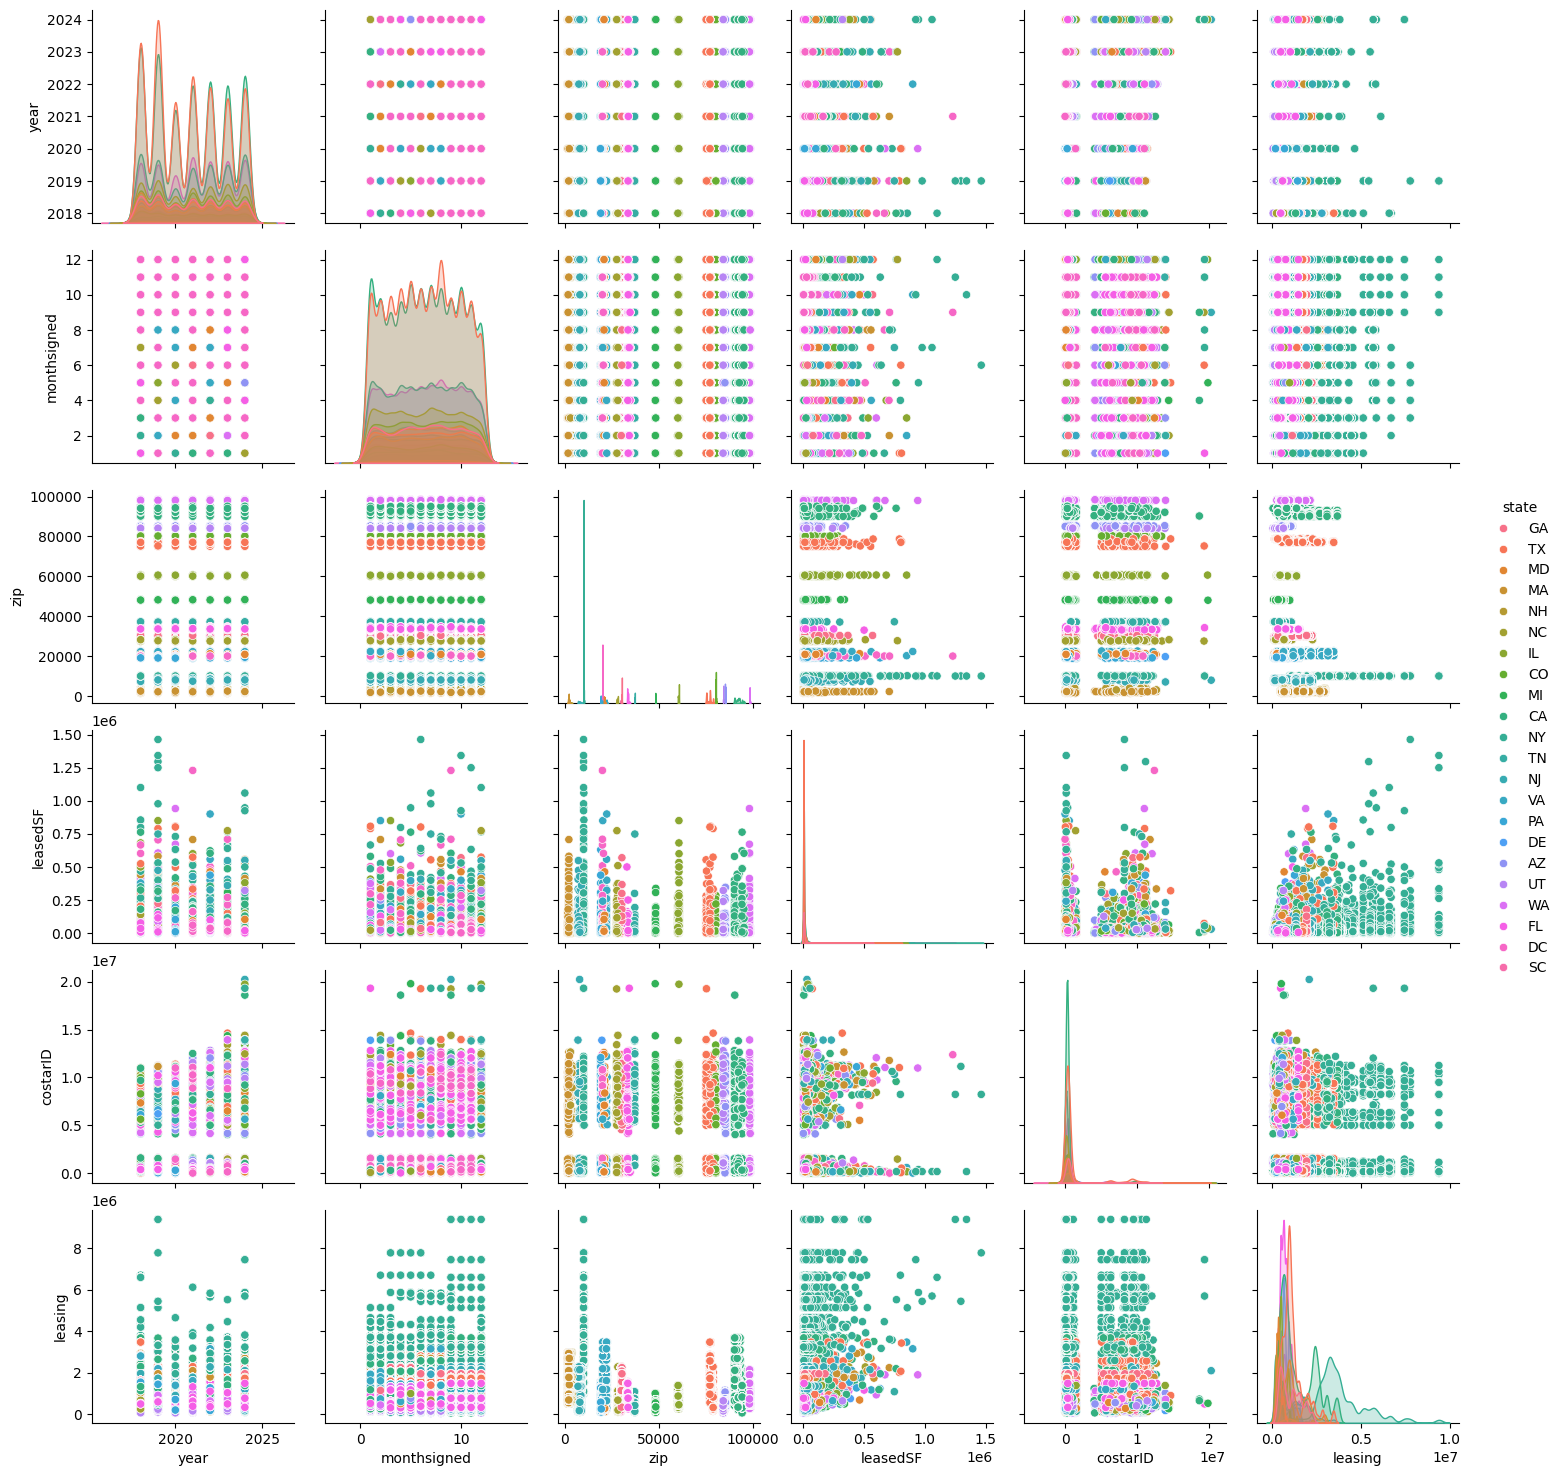

In [ ]:
sns.pairplot(leases_no_price_df, hue='state')

#### How does the area of leased space change per state?

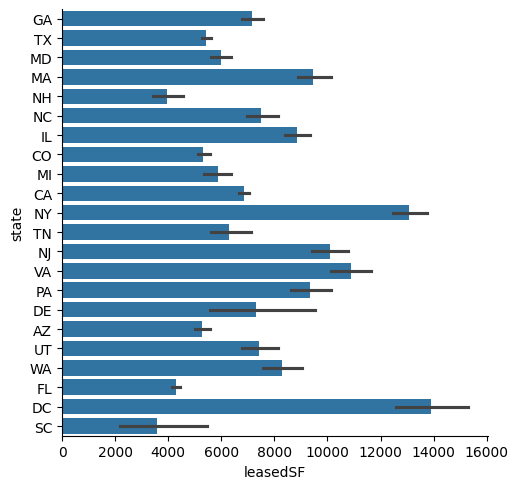

In [54]:
sns.catplot(data=leases_no_price_df, x='leasedSF', y='state', kind='bar');

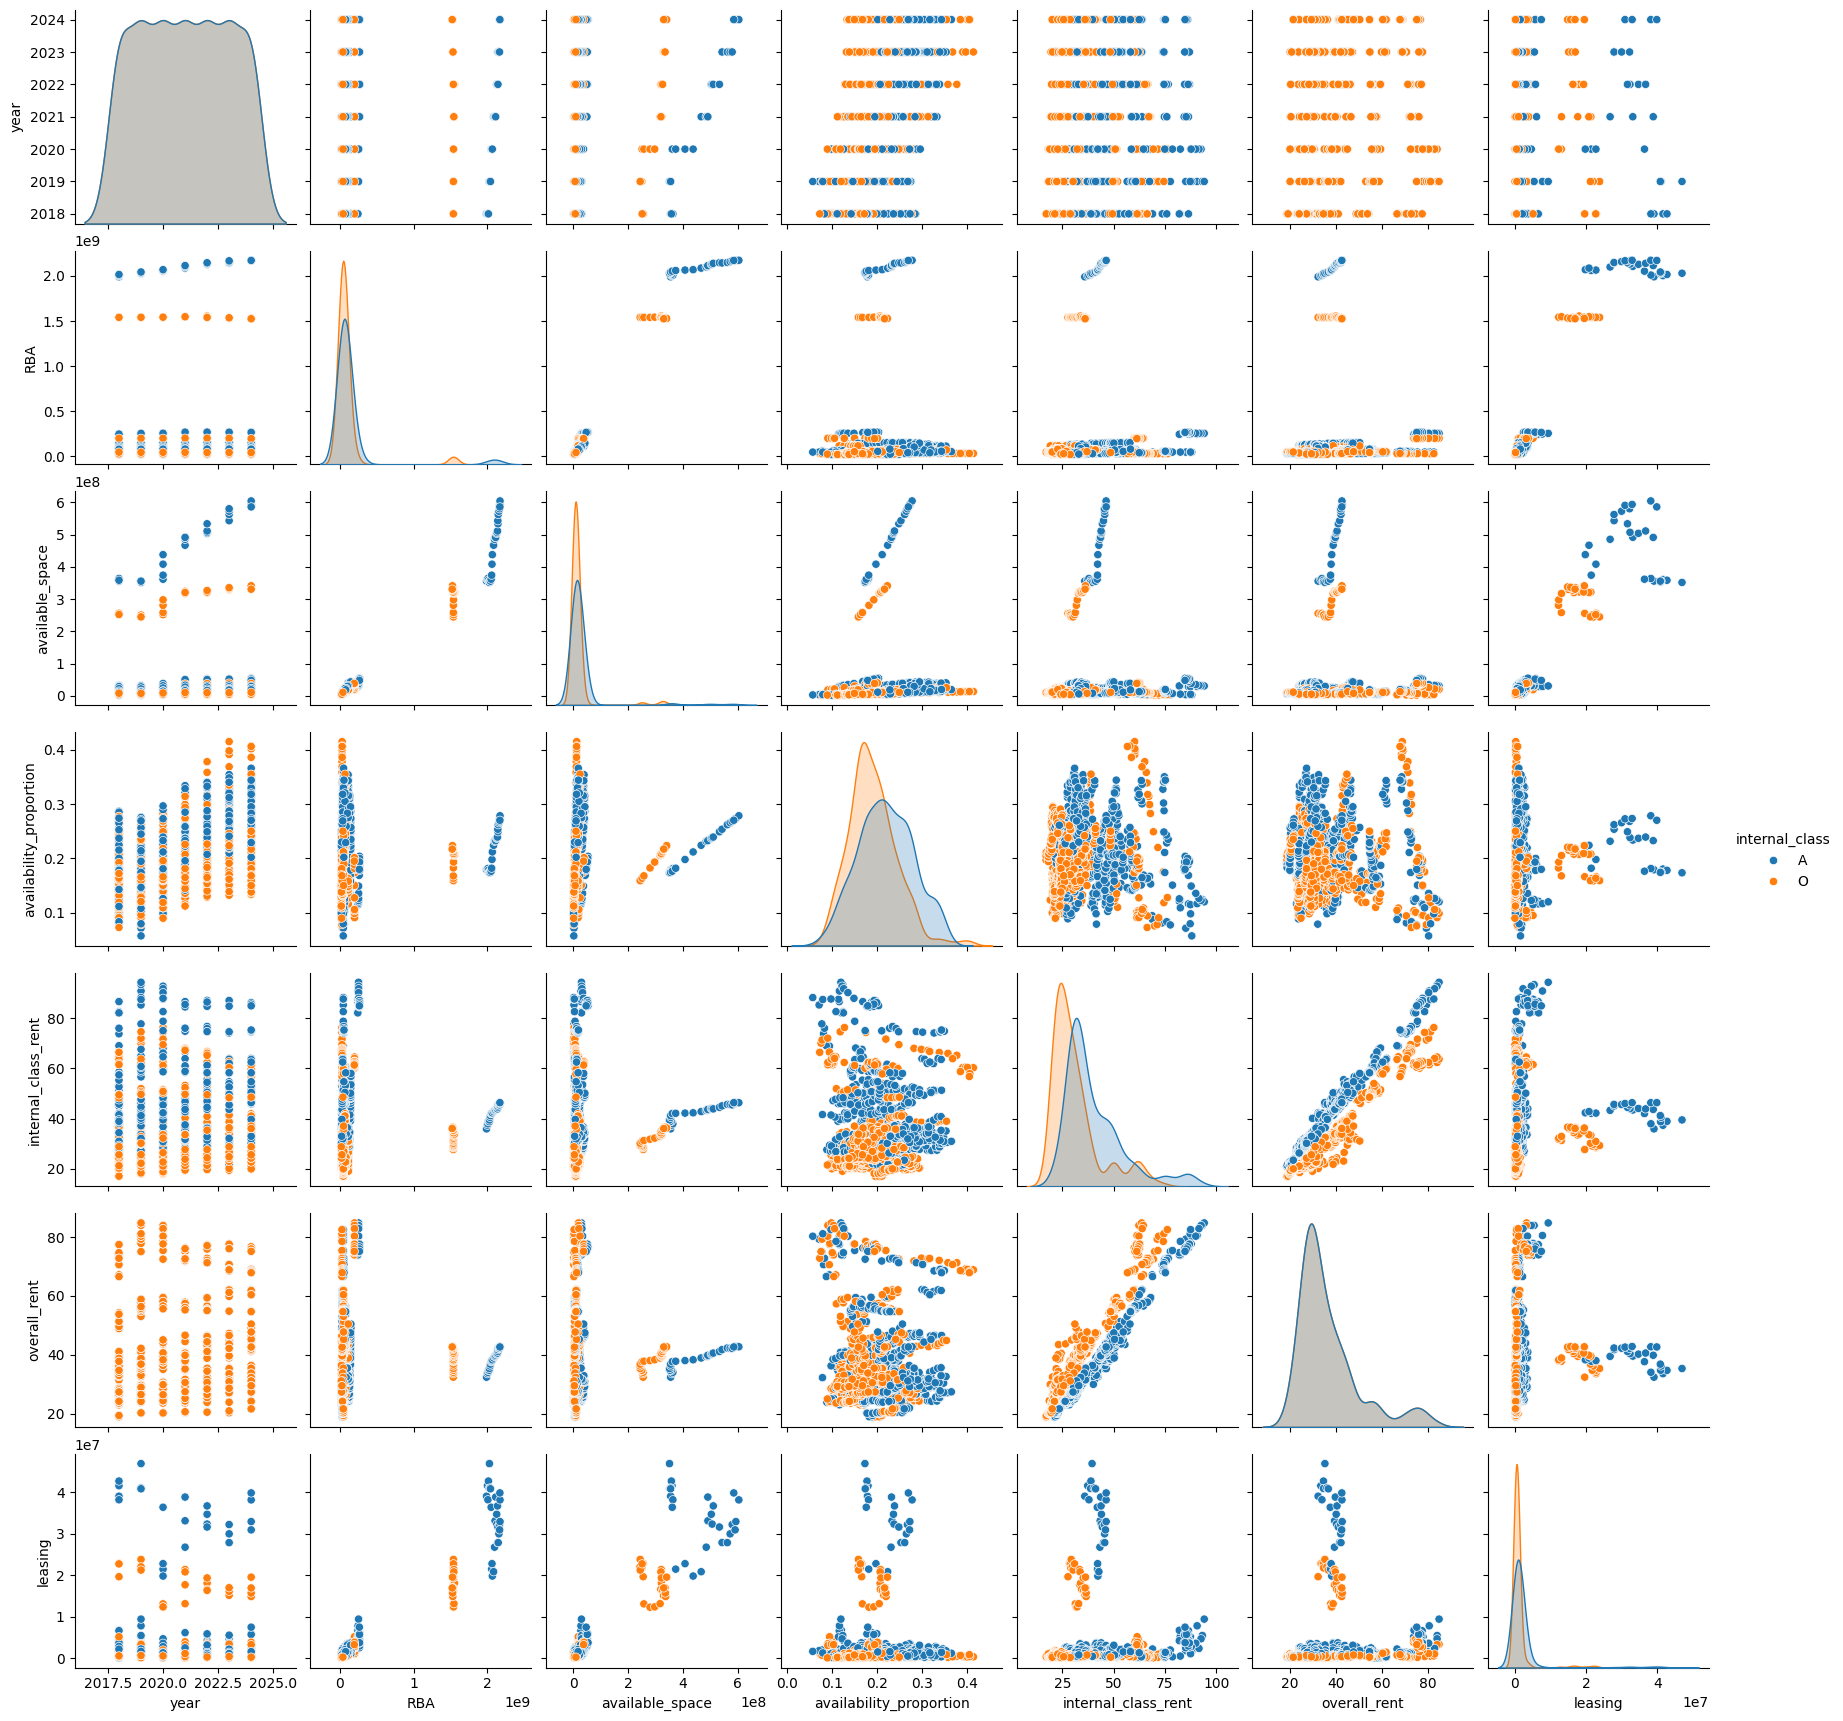

In [40]:
sns.pairplot(prices_nona_df, hue='internal_class');

In [ ]:
sns.catplot()